# Exam prep

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "http://mlg.ucd.ie/modules/COMP30850/transactions.csv"

In [3]:
df = pd.read_csv(url)

In [4]:
df.head()

,day,month,year,source,destination,amount
0,1,October,2024,5793,5179,121.00
1,1,October,2024,5664,5466,75.09
2,1,October,2024,5855,5150,15.60
3,1,October,2024,5855,5150,10.20
4,1,October,2024,5699,5467,184.30


In [5]:
data_strings = df['day'].astype(str) + ' ' + df['month'] + ' ' + df['year'].astype(str)
df['Date'] = pd.to_datetime(data_strings)

In [6]:
df.head()

,day,month,year,source,destination,amount,Date
0,1,October,2024,5793,5179,121.00,2024-10-01
1,1,October,2024,5664,5466,75.09,2024-10-01
2,1,October,2024,5855,5150,15.60,2024-10-01
3,1,October,2024,5855,5150,10.20,2024-10-01
4,1,October,2024,5699,5467,184.30,2024-10-01


In [8]:
static_edges = df.groupby(['source', 'destination'])['amount'].sum().reset_index()

G = nx.from_pandas_edgelist(
    static_edges,
    source='source',
    target='destination',
    edge_attr='amount',
    create_using=nx.DiGraph
)

This approach aggregates transactions by summing amounts, creating a weighted directed graph where edge weights represent total money transferred. This is suitable for analyzing cumulative financial flow between accounts.

In [9]:
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 283
Edges: 510


In [10]:
# density
density = nx.density(G)

# reciprocity
reciprocity = nx.reciprocity(G)

print(f"Density: {density:.4f}")
print(f"Reciprocity: {reciprocity:.4f}")

Density: 0.0064
Reciprocity: 0.0118


A density of 0.0064 means only 0.64% of all possible connections between financial entities exist, indicating a very sparse network where most accounts do not directly interact. A reciprocity of 0.0118 means that for every 100 transactions, only about 1.18 of them are reciprocated (i.e., if A pays B, B also pays A), suggesting a network dominated by one-way payments rather than mutual exchanges.

In [11]:
in_degrees = pd.Series(dict(G.in_degree(weight='amount')))
in_degrees.sort_values(ascending=False).head(10)

5466    55485.37
5467    42515.08
5359    38991.11
5179    37748.68
5050    28010.30
5654    19258.22
5379    18633.26
5150    15151.87
5473    11744.46
5750    11229.21
dtype: float64

In [12]:
out_degrees = pd.Series(dict(G.out_degree(weight='amount')))
out_degrees.sort_values(ascending=False).head(10)

5050    23062.03
5379    19908.61
5172    19726.40
5356    18471.06
5083    18104.30
5705    12392.09
5819    11741.42
5580    11525.35
5150    11492.03
5664    11385.83
dtype: float64

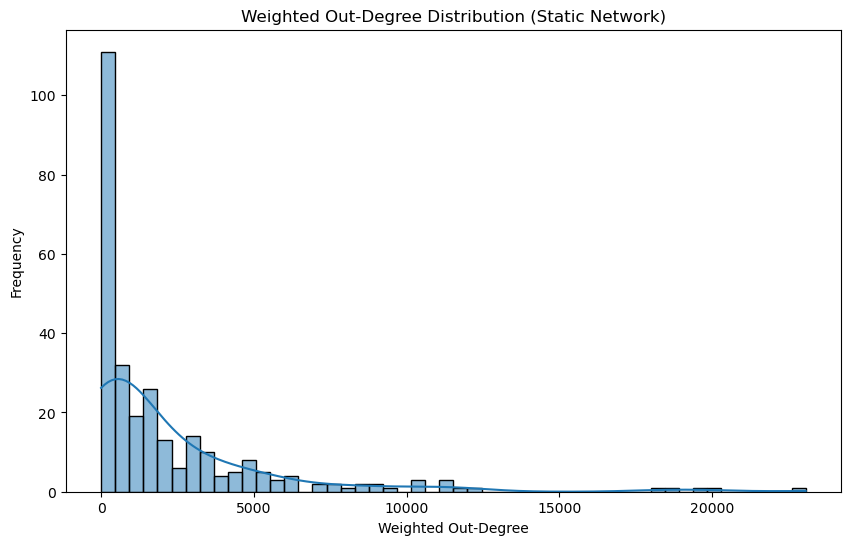

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(out_degrees, bins=50, kde=True)
plt.title('Weighted Out-Degree Distribution (Static Network)')
plt.xlabel('Weighted Out-Degree')
plt.ylabel('Frequency')
plt.show()

Unweighted out-degree measures the number of distinct counterparties a node sends money to, highlighting structural connectivity. Weighted out-degree (or strength) sums the total monetary value, reflecting the intensity of outflows. Unweighted reveals a hub's reach; weighted reveals a hub's liquidity impact. 

### Task 3: Dynamic Network Creation and Analysis
a) Using the transaction dataset, construct a dynamic network that captures how the transaction network evolves over the three-month period. Justify
your choice of time window size

In [34]:
df_time = df.set_index('Date')

time_windows = df_time.groupby(pd.Grouper(freq='W'))

In [35]:
dynamic_metrics = []

for time_period, data in time_windows:
    if data.empty:
        continue

    window_edges = data.groupby(['source', 'destination']).sum().reset_index()

    G_window = nx.from_pandas_edgelist(
        window_edges,
        source='source',
        target='destination',
        edge_attr='amount',
        create_using=nx.DiGraph
    )

    metrics = {
        'Week_ending': time_period.date(),
        'Nodes': G_window.number_of_nodes(),
        'Edges': G_window.number_of_edges(),
        'Density': nx.density(G_window)
    }

    dynamic_metrics.append(metrics)
    

In [36]:
metrics_df = pd.DataFrame(dynamic_metrics)

In [37]:
metrics_df

,Week_ending,Nodes,Edges,Density
0,2024-10-06,145,155,0.007423
1,2024-10-13,152,164,0.007145
2,2024-10-20,147,166,0.007735
3,2024-10-27,140,153,0.007862
4,2024-11-03,152,159,0.006928
5,2024-11-10,138,143,0.007564
6,2024-11-17,129,146,0.008842
7,2024-11-24,140,141,0.007246
8,2024-12-01,163,177,0.006703
9,2024-12-08,174,209,0.006943


The network generally shows an increase in activity towards the end of the year, peaking in December, likely due to holiday spending. The consistent density suggests that new connections are formed proportionally to the increase in active users, maintaining a relatively stable interconnectedness despite fluctuations in overall size. The sharp drop in the last week (2025-01-05) could indicate a post-holiday slowdown or data truncation.